# Estimating country areas using Monte Carlo Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from geopandas import GeoSeries
from shapely.geometry import Point


### Esitmating Area of India

In [2]:
# Loading India's boundary
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url).rename({"ADMIN": "name"}, axis="columns")
india = world[world["NAME"]=="India"].geometry.values[0]
india_m = india.to_crs(epsg=3857) if hasattr(india, "to_crs") else india
india_m = GeoSeries([india]).set_crs(epsg=4326).to_crs(epsg=6933)[0]


In [3]:
'''
    Function using monte carlo simulation to calculate area

    Parameters:
    polygon (shapely Polygon) : shape to estimate
    N (int) : number of random samples

    Returns:
    est_area (float) : estimated area
    inside_ratio (float) : fraction of points inside polygon
'''
def area(polygon, N=10000):
    minx, miny, maxx, maxy = polygon.bounds
    xs = np.random.uniform(minx, maxx, N)
    ys = np.random.uniform(miny, maxy, N)

    inside = 0
    for x, y in zip(xs, ys):
        if polygon.contains(Point(x,y)):
            inside += 1

    inside_ratio = inside/N
    bbox_area = (maxx-minx)*(maxy-miny)
    est_area = inside_ratio*bbox_area
    return est_area/1e6, inside_ratio


In [4]:
N = 1000000
est_area, inside_ratio = area(india_m, N)
true_area = 3287263
error = abs(est_area - true_area)/true_area*100

print(f"Monte Carlo Estimate of India's Area with {N} samples : {est_area:.6f} km^2")
print(f"True area of India : {true_area:.6f} km^2")
print(f"Error in estimation : {error:.2f}%")


Monte Carlo Estimate of India's Area with 1000000 samples : 3143716.125964 km^2
True area of India : 3287263.000000 km^2
Error in estimation : 4.37%


### Estimating Area of United States of America

In [5]:
usa = world[world["NAME"]=="United States of America"].geometry.values[0]
usa_m = usa.to_crs(epsg=3857) if hasattr(usa, "to_crs") else usa
usa_m = GeoSeries([usa]).set_crs(epsg=4326).to_crs(epsg=6933)[0]


In [6]:
N = 1000000
est_area, inside_ratio = area(usa_m, N)
true_area = 9831510
error = abs(est_area - true_area)/true_area*100

print(f"Monte Carlo Estimate of USA's Area with {N} samples : {est_area:.6f} km^2")
print(f"True area of USA : {true_area:.6f} km^2")
print(f"Error in estimation : {error:.2f}%")


Monte Carlo Estimate of USA's Area with 1000000 samples : 9472485.656767 km^2
True area of USA : 9831510.000000 km^2
Error in estimation : 3.65%


### Visualizing Monte Carlo Simulation

In [7]:
def plot_sample_points(polygon, N=5000):
    """Visualize points inside vs outside polygon."""
    minx, miny, maxx, maxy = polygon.bounds
    xs = np.random.uniform(minx, maxx, N)
    ys = np.random.uniform(miny, maxy, N)

    inside_points = []
    outside_points = []
    for x, y in zip(xs, ys):
        if polygon.contains(Point(x, y)):
            inside_points.append((x, y))
        else:
            outside_points.append((x, y))

    inside_points = np.array(inside_points)
    outside_points = np.array(outside_points)

    plt.figure(figsize=(8, 8))
    gpd.GeoSeries(polygon).boundary.plot(color="black")
    if len(inside_points) > 0:
        plt.scatter(inside_points[:,0], inside_points[:,1], c="green", s=2, label="Inside")
    if len(outside_points) > 0:
        plt.scatter(outside_points[:,0], outside_points[:,1], c="red", s=2, label="Outside")
    plt.title(f"Monte Carlo Sampling ({N} points)")
    plt.legend()
    plt.show()


<Figure size 800x800 with 0 Axes>

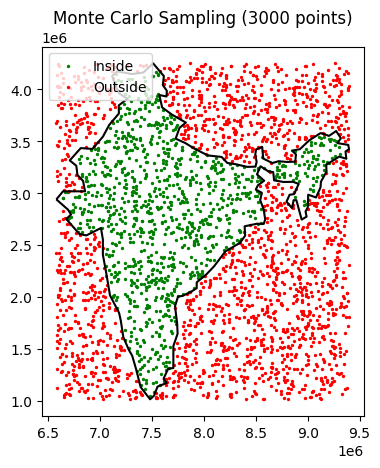

<Figure size 800x800 with 0 Axes>

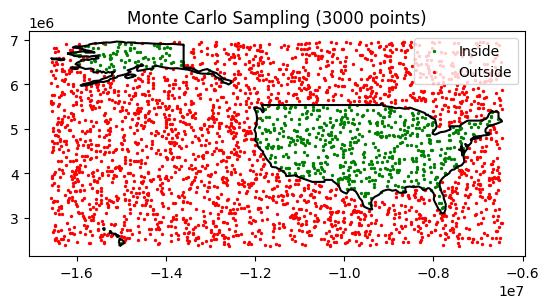

In [8]:
plot_sample_points(india_m, N=3000)
plot_sample_points(usa_m, N=3000)
